In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# =====================================================
# Load Dataset & Basic Preprocessing
# =====================================================

df = pd.read_csv('../Data/data.csv')
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)   

D:\Temp\ipykernel_20168\2830074103.py:5: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../Data/data.csv')


In [3]:
# Store 1 filter karo
store1 = df[df['Store'] == 1]['Sales'].copy()
store1 = store1.sort_index()

print(f"Shape: {store1.shape}")
print(f"Date Range: {store1.index.min()} to {store1.index.max()}")

Shape: (730,)
Date Range: 2013-01-01 00:00:00 to 2014-12-31 00:00:00


In [4]:
split = int(len(store1) * 0.8)

train = store1.iloc[:split]
test  = store1.iloc[split:]

print(f"Train: {train.index[0].date()} to {train.index[-1].date()}")
print(f"Test:  {test.index[0].date()} to {test.index[-1].date()}")
print(f"Train rows: {len(train)}, Test rows: {len(test)}")

Train: 2013-01-01 to 2014-08-07
Test:  2014-08-08 to 2014-12-31
Train rows: 584, Test rows: 146


In [5]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(
    train,
    order=(1, 0, 2),           # p, d, q
    seasonal_order=(1, 1, 1, 7) # P, D, Q, s
)

result = model.fit(disp=False)
print(result.summary())

c:\Users\Nikku\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\Nikku\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                                      SARIMAX Results                                      
Dep. Variable:                               Sales   No. Observations:                  584
Model:             SARIMAX(1, 0, 2)x(1, 1, [1], 7)   Log Likelihood               -4889.004
Date:                             Sat, 18 Jul 2026   AIC                           9790.009
Time:                                     15:34:58   BIC                           9816.156
Sample:                                 01-01-2013   HQIC                          9800.205
                                      - 08-07-2014                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6346      0.091      6.988      0.000       0.457       0.813
ma.L1         -0.4885      

In [6]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Forecast
y_pred = result.forecast(steps=len(test))

# Metrics
mae  = mean_absolute_error(test, y_pred)
rmse = np.sqrt(mean_squared_error(test, y_pred))
accuracy = r2_score(test, y_pred)


print(f"MAE  : {mae:.0f}")
print(f"RMSE : {rmse:.0f}")
print("R2  :", accuracy)

MAE  : 929
RMSE : 1368
R2  : 0.601960505327748


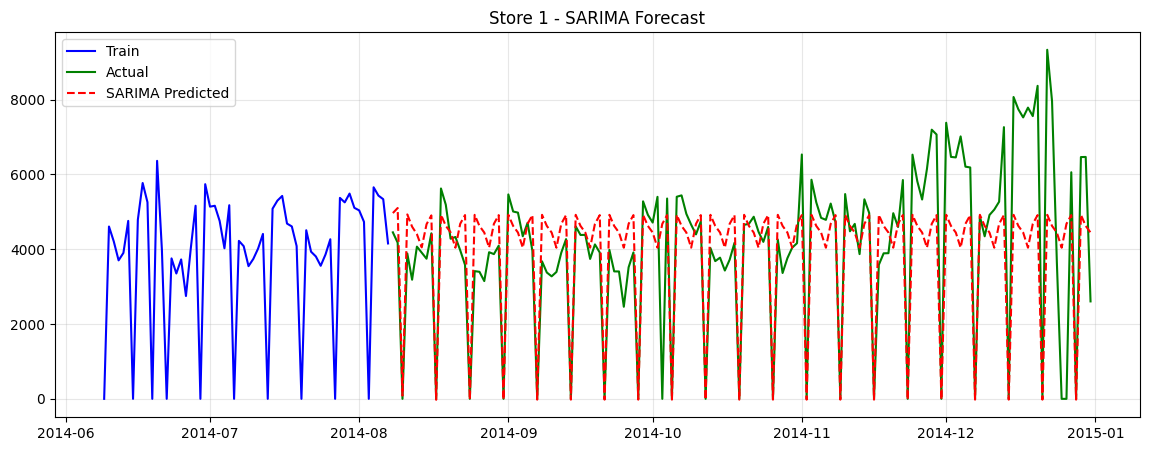

In [7]:
plt.figure(figsize=(14, 5))
plt.plot(train[-60:], label='Train', color='blue')
plt.plot(test, label='Actual', color='green')
plt.plot(y_pred, label='SARIMA Predicted', 
         color='red', linestyle='--')
plt.legend()
plt.title('Store 1 - SARIMA Forecast')
plt.grid(True, alpha=0.3)
plt.show()